In [2]:
# ============================================
# NOTEBOOK 4: EVALUATION - COMPLETE
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_curve, auc, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("="*70)
print("EVALUATION - GENDER CLASSIFICATION")
print("="*70)

# ============================================
# 1. LOAD ALL CHECKPOINTS
# ============================================

print("\n" + "="*70)
print("LOADING CHECKPOINTS")
print("="*70)

# Paths (sesuaikan dengan nama dataset di Kaggle)
MODELING_OUTPUT = '/kaggle/input/data-modelling-face-recognition-ipynb/'  # Output dari notebook 3
SPLIT_OUTPUT = '/kaggle/input/data-splitting-face-recognition/'    # Output dari notebook 2
IMAGE_PATH = '/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba'

# Load modeling metadata
with open(f'{MODELING_OUTPUT}modeling_metadata.pkl', 'rb') as f:
    modeling_metadata = pickle.load(f)

print("✓ Modeling metadata loaded")
print(f"  Epochs trained: {modeling_metadata['epochs']}")
print(f"  Best model: {modeling_metadata['best_model_name']}")

# Load best model info
with open(f'{MODELING_OUTPUT}best_model_info.pkl', 'rb') as f:
    best_model_info = pickle.load(f)

print(f"✓ Best model info loaded")
print(f"  Val Accuracy: {best_model_info['val_accuracy']:.4f}")

# Load best model
best_model = load_model(f'{MODELING_OUTPUT}best_model.h5')
print(f"✓ Best model loaded")

# Load comparison
comparison_df = pd.read_csv(f'{MODELING_OUTPUT}models_comparison.csv')
print(f"✓ Comparison data loaded ({len(comparison_df)} models)")

# Extract configuration
TARGET_SIZE = tuple(modeling_metadata['target_size'])
BATCH_SIZE = modeling_metadata['batch_size']
CLASS_INDICES = modeling_metadata['class_indices']

print(f"\nConfiguration:")
print(f"  Target size: {TARGET_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Class indices: {CLASS_INDICES}")

# ============================================
# 2. LOAD TEST DATA
# ============================================

print("\n" + "="*70)
print("LOADING TEST DATA")
print("="*70)

# Load test split
test_df = pd.read_csv(f'{SPLIT_OUTPUT}test_split.csv')
print(f"✓ Test data loaded: {len(test_df)} samples")

# Ensure label is string
if test_df['label'].dtype != 'object':
    test_df['label'] = test_df['label'].astype(str)

# Display distribution
print("\nTest set gender distribution:")
print(test_df['Gender'].value_counts())

# Create test generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False  # IMPORTANT: Don't shuffle for evaluation
)

print(f"✓ Test generator created")
print(f"  Total batches: {len(test_generator)}")
print(f"  Samples: {test_generator.samples}")

2025-10-24 04:32:07.175857: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761280327.355156      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761280327.430401      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


EVALUATION - GENDER CLASSIFICATION

LOADING CHECKPOINTS
✓ Modeling metadata loaded
  Epochs trained: 50
  Best model: High_Capacity
✓ Best model info loaded
  Val Accuracy: 0.9210


I0000 00:00:1761280338.775844      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✓ Best model loaded
✓ Comparison data loaded (3 models)

Configuration:
  Target size: (128, 128)
  Batch size: 32
  Class indices: {'0': 0, '1': 1}

LOADING TEST DATA
✓ Test data loaded: 25331 samples

Test set gender distribution:
Gender
Female    12666
Male      12665
Name: count, dtype: int64
Found 25331 validated image filenames belonging to 2 classes.
✓ Test generator created
  Total batches: 792
  Samples: 25331


In [3]:
# ============================================
# 4.1. PREDICTION ON TEST DATA
# ============================================

print("\n" + "="*70)
print("4.1. PERFORMING PREDICTIONS ON TEST DATA")
print("="*70)

# Get predictions
test_generator.reset()
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_generator.classes

print(f"\n✓ Predictions completed")
print(f"  Predictions shape: {y_pred_probs.shape}")
print(f"  True labels shape: {y_true.shape}")


4.1. PERFORMING PREDICTIONS ON TEST DATA


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1761280467.862291      97 service.cc:148] XLA service 0x79806800cf80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761280467.862890      97 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761280468.009811      97 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/792 ━━━━━━━━━━━━━━━━━━━━ 1:00:23 5s/step

I0000 00:00:1761280471.723779      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


792/792 ━━━━━━━━━━━━━━━━━━━━ 203s 251ms/step

✓ Predictions completed
  Predictions shape: (25331, 1)


AttributeError: 'list' object has no attribute 'shape'

In [5]:
# Add predictions to dataframe
test_df['y_true'] = y_true
test_df['y_pred'] = y_pred
test_df['y_pred_prob'] = y_pred_probs.flatten()
test_df['Predicted_Gender'] = test_df['y_pred'].apply(lambda x: 'Male' if x == 1 else 'Female')
test_df['Correct'] = test_df['y_true'] == test_df['y_pred']

print(f"\n✓ Predictions added to dataframe")


✓ Predictions added to dataframe


In [6]:
# ============================================
# 4.1.1. DATAFRAME: ACTUAL VS PREDICTED
# ============================================

print("\n" + "="*70)
print("4.1.1. DATAFRAME: ACTUAL VS PREDICTED LABELS")
print("="*70)

# Create results dataframe
results_df = test_df[['image_id', 'Gender', 'Predicted_Gender', 'y_pred_prob', 'Correct']].copy()
results_df.columns = ['Image', 'Actual_Gender', 'Predicted_Gender', 'Confidence', 'Correct']

print("\nSample predictions:")
print(results_df.head(20).to_string(index=False))

# Save results
results_df.to_csv('/kaggle/working/test_predictions.csv', index=False)
print(f"\n✓ Saved: test_predictions.csv")

# Statistics
correct_count = results_df['Correct'].sum()
total_count = len(results_df)
accuracy = correct_count / total_count

print(f"\n" + "="*50)
print("PREDICTION STATISTICS")
print("="*50)
print(f"Total predictions: {total_count}")
print(f"Correct predictions: {correct_count}")
print(f"Incorrect predictions: {total_count - correct_count}")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")



4.1.1. DATAFRAME: ACTUAL VS PREDICTED LABELS

Sample predictions:
     Image Actual_Gender Predicted_Gender  Confidence  Correct
142158.jpg          Male             Male    0.998624     True
196561.jpg        Female           Female    0.001479     True
146582.jpg          Male             Male    0.998200     True
042098.jpg        Female           Female    0.210862     True
108199.jpg          Male             Male    0.988551     True
037112.jpg          Male             Male    0.995965     True
120907.jpg          Male             Male    0.995290     True
096055.jpg          Male           Female    0.117195    False
176827.jpg          Male             Male    0.996783     True
069412.jpg          Male             Male    0.996861     True
145085.jpg          Male             Male    0.996576     True
076462.jpg        Female           Female    0.000191     True
035541.jpg          Male             Male    0.982960     True
145643.jpg        Female           Female    0.0002


4.1.2. DISPLAYING IMAGES WITH GENDER LABELS & PREDICTIONS


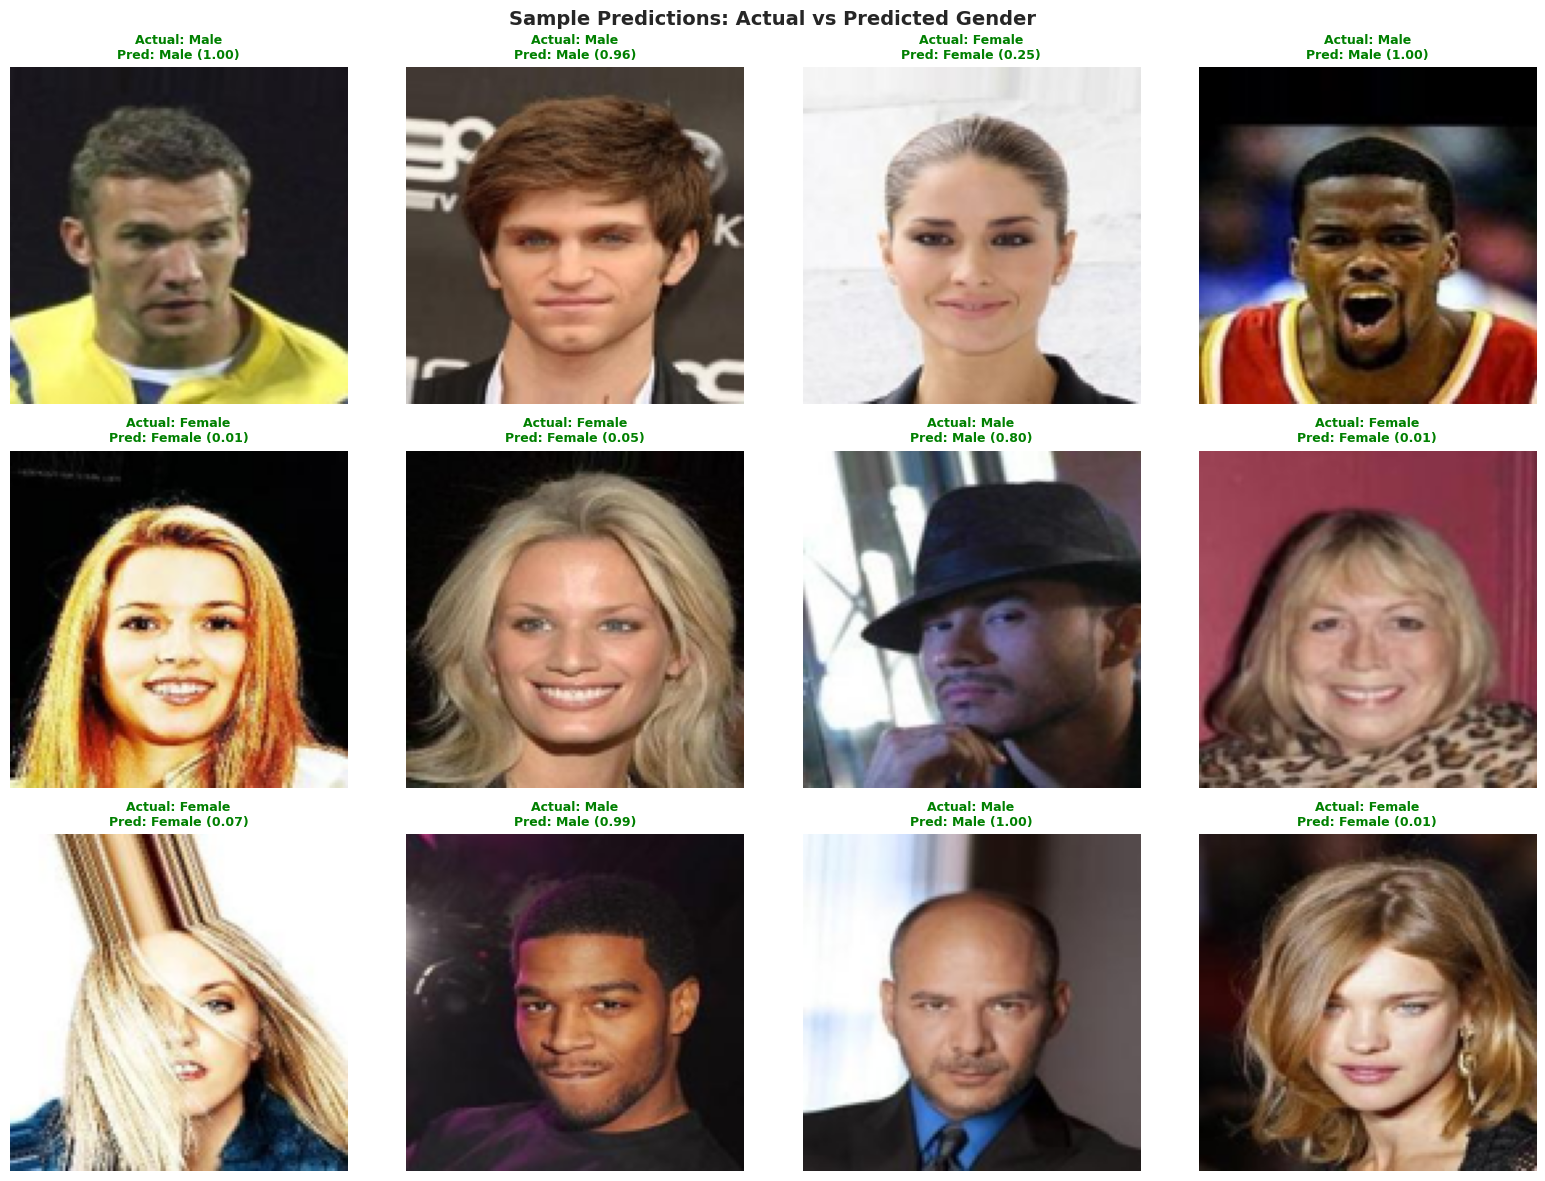

✓ Saved: sample_predictions.png


In [7]:
# ============================================
# 4.1.2. DISPLAY IMAGES WITH LABELS AND PREDICTIONS
# ============================================

print("\n" + "="*70)
print("4.1.2. DISPLAYING IMAGES WITH GENDER LABELS & PREDICTIONS")
print("="*70)

# Sample 12 random images
np.random.seed(42)
sample_indices = np.random.choice(len(test_df), 12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, sample_idx in enumerate(sample_indices):
    row = test_df.iloc[sample_idx]
    
    # Load image
    img = Image.open(row['filepath']).resize(TARGET_SIZE)
    
    # Get info
    actual = row['Gender']
    predicted = row['Predicted_Gender']
    confidence = row['y_pred_prob']
    is_correct = row['Correct']
    
    # Display
    axes[idx].imshow(img)
    
    # Color: green if correct, red if wrong
    color = 'green' if is_correct else 'red'
    title = f"Actual: {actual}\nPred: {predicted} ({confidence:.2f})"
    
    axes[idx].set_title(title, fontsize=9, color=color, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Predictions: Actual vs Predicted Gender', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: sample_predictions.png")


4.2. CONFUSION MATRIX

Confusion Matrix:
[[11470  1196]
 [  818 11847]]

True Negatives (Female→Female): 11470
False Positives (Female→Male): 1196
False Negatives (Male→Female): 818
True Positives (Male→Male): 11847


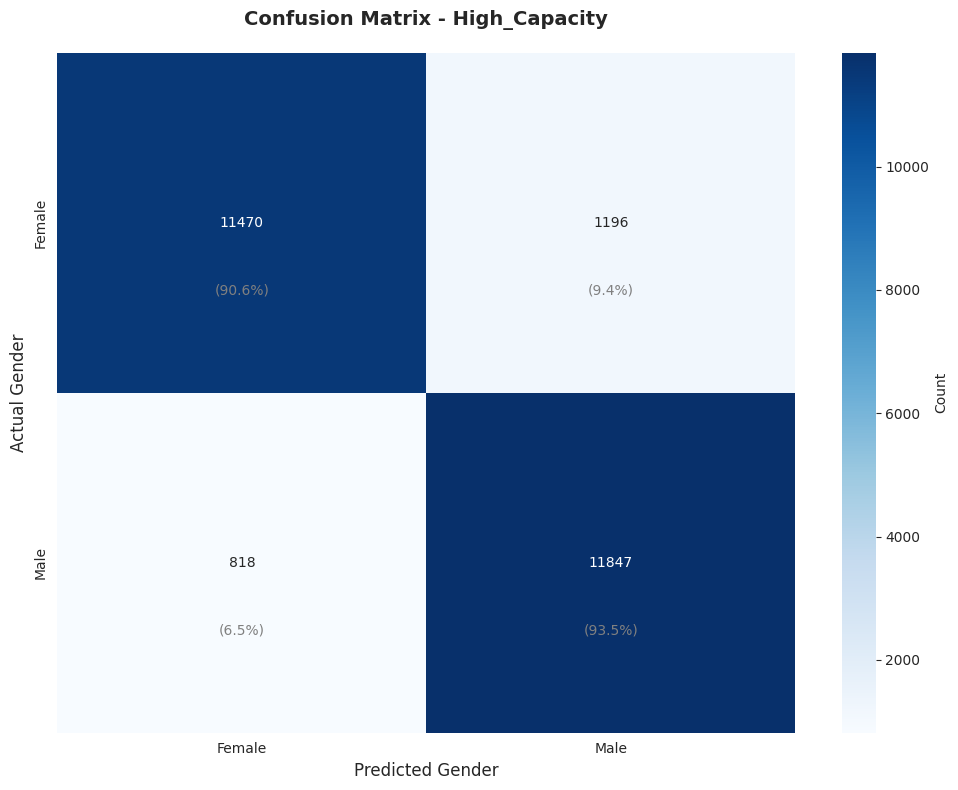


✓ Saved: confusion_matrix.png


In [8]:
# ============================================
# 4.2. CONFUSION MATRIX
# ============================================

print("\n" + "="*70)
print("4.2. CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives (Female→Female): {cm[0,0]}")
print(f"False Positives (Female→Male): {cm[0,1]}")
print(f"False Negatives (Male→Female): {cm[1,0]}")
print(f"True Positives (Male→Male): {cm[1,1]}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Female', 'Male'],
            yticklabels=['Female', 'Male'],
            cbar_kws={'label': 'Count'},
            ax=ax)

ax.set_title(f'Confusion Matrix - {best_model_info["best_model_name"]}', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Actual Gender', fontsize=12)
ax.set_xlabel('Predicted Gender', fontsize=12)

# Add percentages
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm[i].sum() * 100
        ax.text(j+0.5, i+0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: confusion_matrix.png")


4.3. EVALUATION METRICS

OVERALL METRICS
Accuracy:  0.9205
Precision: 0.9083
Recall:    0.9354
F1-Score:  0.9217
ROC AUC:   0.9770

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Female       0.93      0.91      0.92     12666
        Male       0.91      0.94      0.92     12665

    accuracy                           0.92     25331
   macro avg       0.92      0.92      0.92     25331
weighted avg       0.92      0.92      0.92     25331


✓ Saved: classification_report.txt


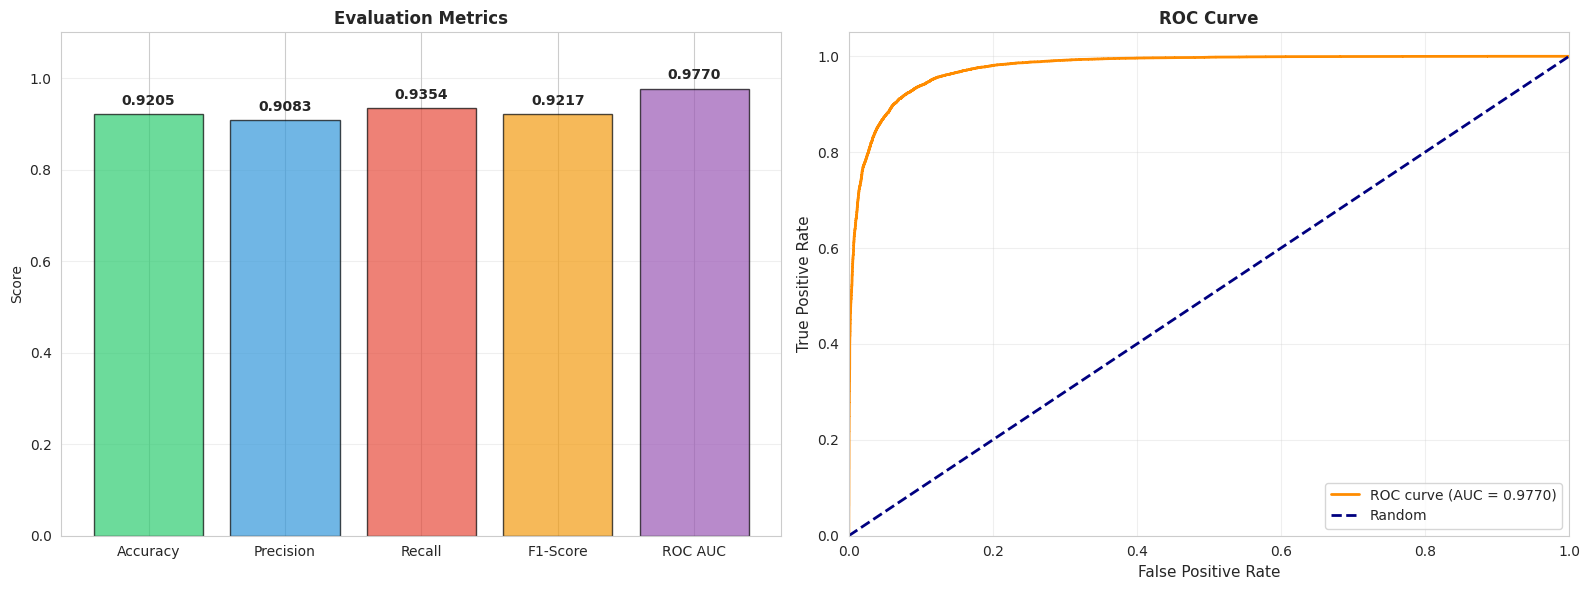

✓ Saved: evaluation_metrics.png


In [9]:
# ============================================
# 4.3. EVALUATION METRICS
# ============================================

print("\n" + "="*70)
print("4.3. EVALUATION METRICS")
print("="*70)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# ROC AUC
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Classification report
class_names = ['Female', 'Male']
report = classification_report(y_true, y_pred, target_names=class_names)

print("\n" + "="*50)
print("OVERALL METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(report)

# Save report
with open('/kaggle/working/classification_report.txt', 'w') as f:
    f.write("="*50 + "\n")
    f.write("EVALUATION METRICS\n")
    f.write("="*50 + "\n\n")
    f.write(f"Model: {best_model_info['best_model_name']}\n")
    f.write(f"Test Samples: {len(y_true)}\n\n")
    f.write(f"Accuracy:  {accuracy:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall:    {recall:.4f}\n")
    f.write(f"F1-Score:  {f1:.4f}\n")
    f.write(f"ROC AUC:   {roc_auc:.4f}\n\n")
    f.write("="*50 + "\n")
    f.write("CLASSIFICATION REPORT\n")
    f.write("="*50 + "\n\n")
    f.write(report)

print("\n✓ Saved: classification_report.txt")

# Metrics visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
metrics_values = [accuracy, precision, recall, f1, roc_auc]
colors_metrics = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

axes[0].bar(metrics_names, metrics_values, color=colors_metrics, alpha=0.7, edgecolor='black')
axes[0].set_title('Evaluation Metrics', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim([0, 1.1])
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(metrics_values):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# ROC Curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: evaluation_metrics.png")


4.4. DISPLAYING MISCLASSIFIED MALE IMAGES
Total misclassified Male images: 818


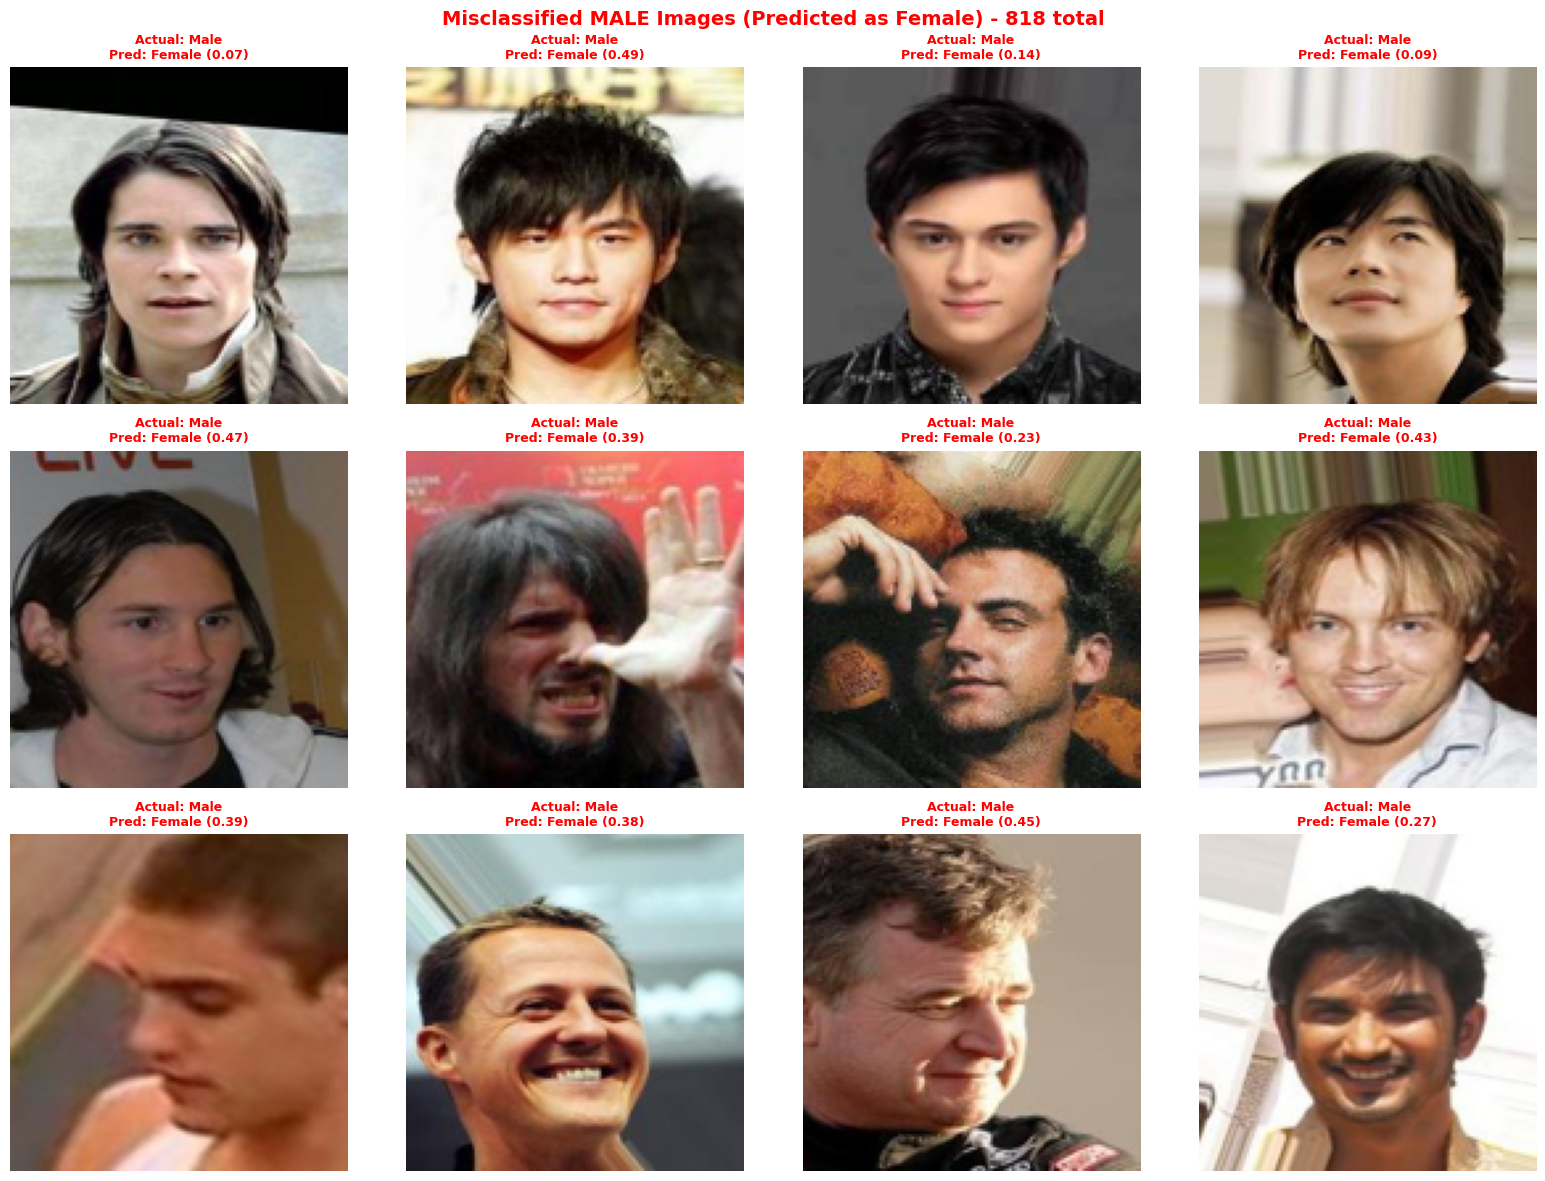

✓ Saved: misclassified_male.png


In [10]:
# ============================================
# 4.4. MISCLASSIFIED MALE IMAGES
# ============================================

print("\n" + "="*70)
print("4.4. DISPLAYING MISCLASSIFIED MALE IMAGES")
print("="*70)

# Filter: Actual=Male, Predicted=Female
male_misclassified = test_df[(test_df['Gender'] == 'Male') & 
                               (test_df['Predicted_Gender'] == 'Female')]

print(f"Total misclassified Male images: {len(male_misclassified)}")

if len(male_misclassified) > 0:
    # Show up to 12 samples
    n_samples = min(12, len(male_misclassified))
    sample_male_wrong = male_misclassified.sample(n=n_samples, random_state=42)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()
    
    for idx, (_, row) in enumerate(sample_male_wrong.iterrows()):
        if idx >= 12:
            break
            
        # Load image
        img = Image.open(row['filepath']).resize(TARGET_SIZE)
        
        # Display
        axes[idx].imshow(img)
        title = f"Actual: Male\nPred: Female ({row['y_pred_prob']:.2f})"
        axes[idx].set_title(title, fontsize=9, color='red', fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(n_samples, 12):
        axes[idx].axis('off')
    
    plt.suptitle(f'Misclassified MALE Images (Predicted as Female) - {len(male_misclassified)} total', 
                 fontsize=14, fontweight='bold', color='red')
    plt.tight_layout()
    plt.savefig('/kaggle/working/misclassified_male.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Saved: misclassified_male.png")
else:
    print("✓ No misclassified Male images!")


4.5. DISPLAYING MISCLASSIFIED FEMALE IMAGES
Total misclassified Female images: 1196


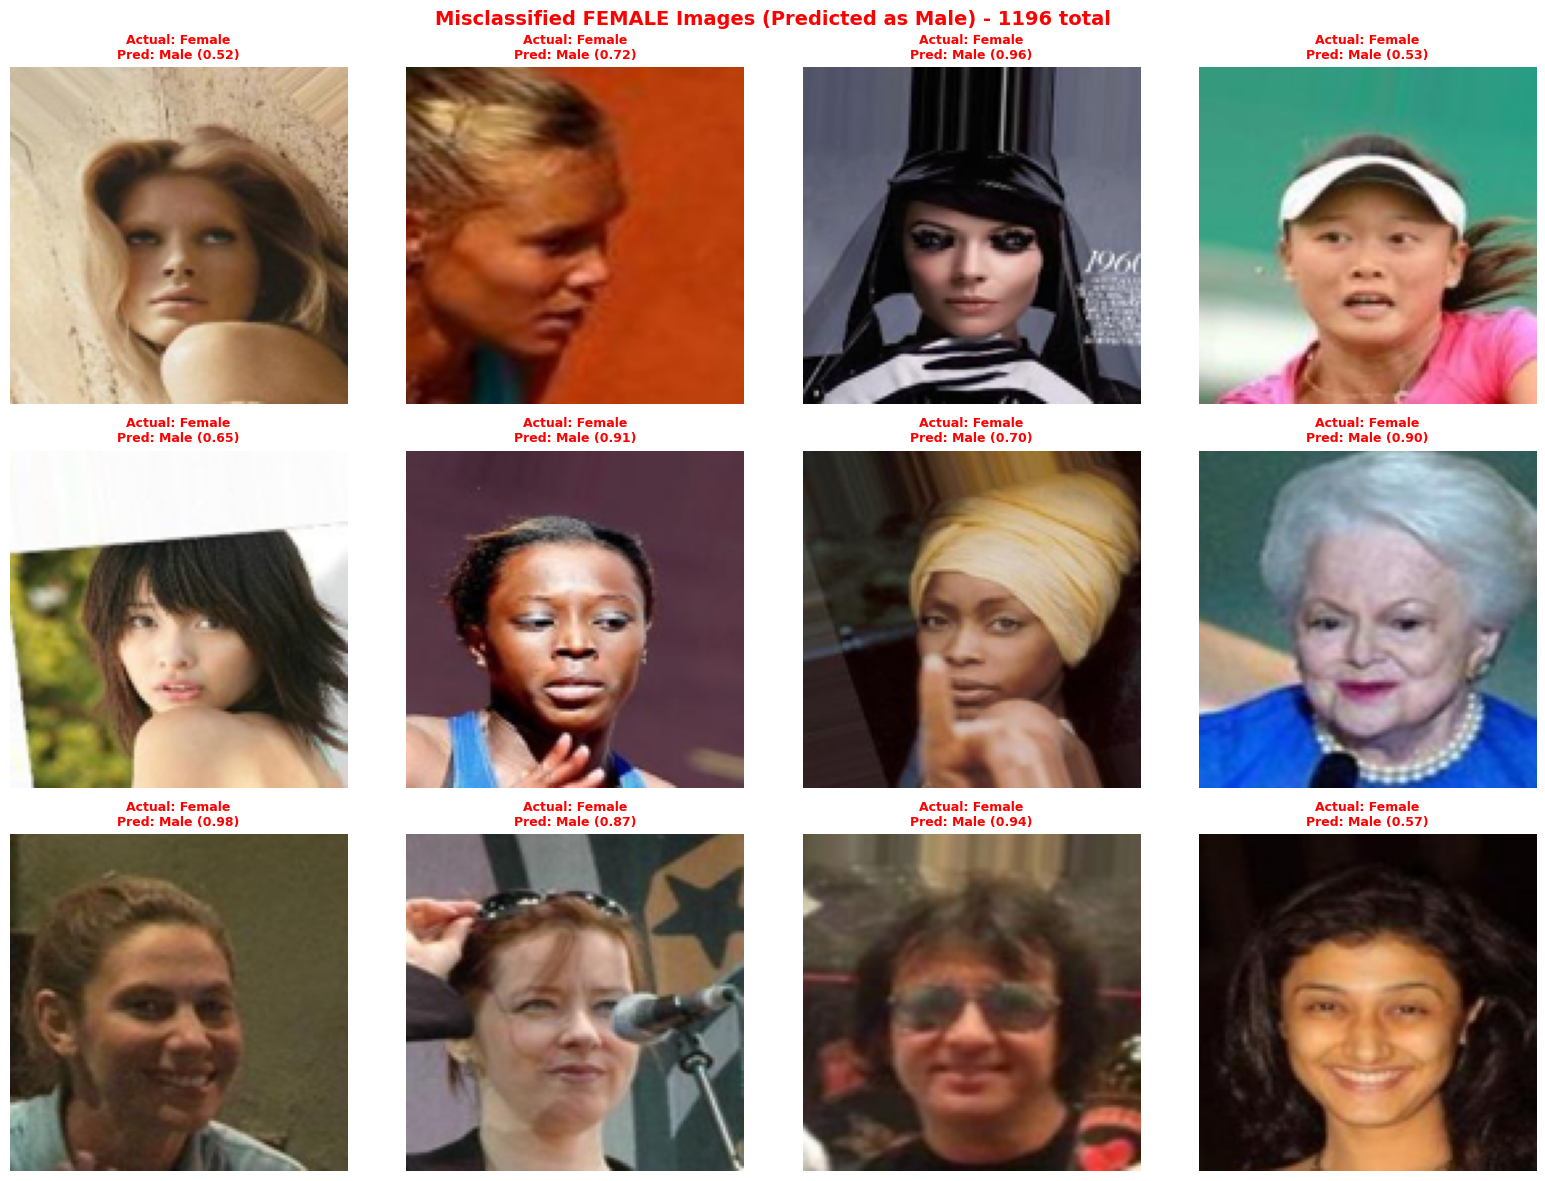

✓ Saved: misclassified_female.png


In [11]:
# ============================================
# 4.5. MISCLASSIFIED FEMALE IMAGES
# ============================================

print("\n" + "="*70)
print("4.5. DISPLAYING MISCLASSIFIED FEMALE IMAGES")
print("="*70)

# Filter: Actual=Female, Predicted=Male
female_misclassified = test_df[(test_df['Gender'] == 'Female') & 
                                 (test_df['Predicted_Gender'] == 'Male')]

print(f"Total misclassified Female images: {len(female_misclassified)}")

if len(female_misclassified) > 0:
    # Show up to 12 samples
    n_samples = min(12, len(female_misclassified))
    sample_female_wrong = female_misclassified.sample(n=n_samples, random_state=42)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()
    
    for idx, (_, row) in enumerate(sample_female_wrong.iterrows()):
        if idx >= 12:
            break
            
        # Load image
        img = Image.open(row['filepath']).resize(TARGET_SIZE)
        
        # Display
        axes[idx].imshow(img)
        title = f"Actual: Female\nPred: Male ({row['y_pred_prob']:.2f})"
        axes[idx].set_title(title, fontsize=9, color='red', fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(n_samples, 12):
        axes[idx].axis('off')
    
    plt.suptitle(f'Misclassified FEMALE Images (Predicted as Male) - {len(female_misclassified)} total', 
                 fontsize=14, fontweight='bold', color='red')
    plt.tight_layout()
    plt.savefig('/kaggle/working/misclassified_female.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Saved: misclassified_female.png")
else:
    print("✓ No misclassified Female images!")


In [13]:
# ============================================
# SAVE FINAL EVALUATION RESULTS
# ============================================

print("\n" + "="*70)
print("SAVING EVALUATION RESULTS")
print("="*70)

# Helper function to convert to list safely
def to_list(data):
    """Convert data to list, handling both numpy arrays and lists"""
    if isinstance(data, np.ndarray):
        return data.tolist()
    elif isinstance(data, list):
        return data
    else:
        return list(data)

# Create evaluation results dictionary
evaluation_results = {
    'model_name': best_model_info['best_model_name'],
    'test_samples': len(y_true),
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc),
    'confusion_matrix': cm.tolist() if isinstance(cm, np.ndarray) else cm,
    'male_misclassified': int(len(male_misclassified)),
    'female_misclassified': int(len(female_misclassified)),
    'y_true': to_list(y_true),
    'y_pred': to_list(y_pred),
    'y_pred_probs': to_list(y_pred_probs.flatten()) if isinstance(y_pred_probs, np.ndarray) else to_list(y_pred_probs)
}

# Save to pickle
with open('/kaggle/working/evaluation_results.pkl', 'wb') as f:
    pickle.dump(evaluation_results, f)

print("✓ Saved: evaluation_results.pkl")

# Also save as JSON (more portable)
import json

# Create JSON-compatible version (without numpy types)
evaluation_results_json = {
    'model_name': str(best_model_info['best_model_name']),
    'test_samples': int(len(y_true)),
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc),
    'confusion_matrix': cm.tolist() if isinstance(cm, np.ndarray) else cm,
    'male_misclassified': int(len(male_misclassified)),
    'female_misclassified': int(len(female_misclassified))
}

with open('/kaggle/working/evaluation_results.json', 'w') as f:
    json.dump(evaluation_results_json, f, indent=4)

print("✓ Saved: evaluation_results.json")

# Create summary statistics
summary_stats = {
    'Total Test Samples': len(y_true),
    'Correct Predictions': int((y_true == y_pred).sum() if isinstance(y_true, np.ndarray) else sum([t == p for t, p in zip(y_true, y_pred)])),
    'Incorrect Predictions': int((y_true != y_pred).sum() if isinstance(y_true, np.ndarray) else sum([t != p for t, p in zip(y_true, y_pred)])),
    'Accuracy': f'{accuracy:.4f}',
    'Precision': f'{precision:.4f}',
    'Recall': f'{recall:.4f}',
    'F1-Score': f'{f1:.4f}',
    'ROC AUC': f'{roc_auc:.4f}',
    'Male Misclassified': len(male_misclassified),
    'Female Misclassified': len(female_misclassified)
}

# Save summary as text
with open('/kaggle/working/evaluation_summary.txt', 'w') as f:
    f.write("="*70 + "\n")
    f.write("EVALUATION SUMMARY\n")
    f.write("="*70 + "\n\n")
    f.write(f"Model: {best_model_info['best_model_name']}\n")
    f.write(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    for key, value in summary_stats.items():
        f.write(f"{key:25s}: {value}\n")
    
    f.write("\n" + "="*70 + "\n")
    f.write("CONFUSION MATRIX\n")
    f.write("="*70 + "\n\n")
    f.write(f"                    Predicted\n")
    f.write(f"                Female    Male\n")
    f.write(f"Actual Female   {cm[0,0]:6d}  {cm[0,1]:6d}\n")
    f.write(f"       Male     {cm[1,0]:6d}  {cm[1,1]:6d}\n")

print("✓ Saved: evaluation_summary.txt")

print("\n" + "="*70)
print("EVALUATION COMPLETED!")
print("="*70)
print("\nOutput files:")
print("  1. test_predictions.csv")
print("  2. sample_predictions.png")
print("  3. confusion_matrix.png")
print("  4. evaluation_metrics.png")
print("  5. classification_report.txt")
print("  6. misclassified_male.png")
print("  7. misclassified_female.png")
print("  8. evaluation_results.pkl")
print("  9. evaluation_results.json")
print(" 10. evaluation_summary.txt")

print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)
for key, value in summary_stats.items():
    print(f"{key:25s}: {value}")

print(f"\n✓ All evaluation steps completed successfully! 🎉")


SAVING EVALUATION RESULTS
✓ Saved: evaluation_results.pkl
✓ Saved: evaluation_results.json
✓ Saved: evaluation_summary.txt

EVALUATION COMPLETED!

Output files:
  1. test_predictions.csv
  2. sample_predictions.png
  3. confusion_matrix.png
  4. evaluation_metrics.png
  5. classification_report.txt
  6. misclassified_male.png
  7. misclassified_female.png
  8. evaluation_results.pkl
  9. evaluation_results.json
 10. evaluation_summary.txt

FINAL RESULTS
Total Test Samples       : 25331
Correct Predictions      : 23317
Incorrect Predictions    : 2014
Accuracy                 : 0.9205
Precision                : 0.9083
Recall                   : 0.9354
F1-Score                 : 0.9217
ROC AUC                  : 0.9770
Male Misclassified       : 818
Female Misclassified     : 1196

✓ All evaluation steps completed successfully! 🎉
